# Stage 3: Data Fundamentals — Titanic Dataset

Goal: go from raw messy data to a clean, leakage-free train/val/test split, with reasoning documented at each step.

Fill in each code cell yourself. Guiding questions are there to make you think before you code, not to answer for you.

## 1. Load the data + first look

Load with `sns.load_dataset('titanic')` or `pd.read_csv('train.csv')`.

Guiding questions:
- What does `.info()` tell you about missing values and data types?
- What does `.describe()` tell you about the numerical columns — any values that look suspicious (min/max)?
- What's the target column, and what does the class balance look like (`.value_counts()`)?

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#This covers loading, cleaning, visualizing, and splitting the data — everything for this stage.
#pip install jupyter pandas numpy matplotlib seaborn scikit-learn
# TODO: load the dataset
data = sns.load_dataset('titanic')



In [59]:
# TODO: .info(), .describe(), .head(), target value_counts()
data.info() # tells you about the columns, non-null counts, and data type
data.describe() # tells your the statistics
data.head()
data.value_counts() # tells you specifically about a coulmns info value_counts(target)





<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


survived  pclass  sex     age   sibsp  parch  fare     embarked  class   who    adult_male  deck  embark_town  alive  alone
1         1       female  24.0  0      0      69.3000  C         First   woman  False       B     Cherbourg    yes    True     2
                          38.0  1      0      71.2833  C         First   woman  False       C     Cherbourg    yes    False    1
                          35.0  1      0      53.1000  S         First   woman  False       C     Southampton  yes    False    1
0         1       male    54.0  0      0      51.8625  S         First   man    True        E     Southampton  no     True     1
1         3       female  4.0   1      1      16.7000  S         Third   child  False       G     Southampton  yes    False    1
                                                                                                                              ..
0         3       male    32.0  0      0      7.7500   Q         Second  man    True        G     Quee

## 2. Exploratory Data Analysis

Guiding questions:
- Which columns have missing values, and how much (%) is missing in each?
- Does survival rate differ by sex? By passenger class? Plot it.
- Are there any correlations between numerical features worth noting (`.corr()` + heatmap)?
- Any obvious outliers in `fare` or `age`? Visualize with a boxplot or histogram.

In [41]:
# TODO: missing value % per column
rows, columns = data.shape
entries = rows
for column, count in data.count().items():
    if( (1-(count/entries))==0.0):
        continue
    print(column,":", round(1-(count/entries),5))


age : 0.19865
embarked : 0.00224
deck : 0.77217
embark_town : 0.00224


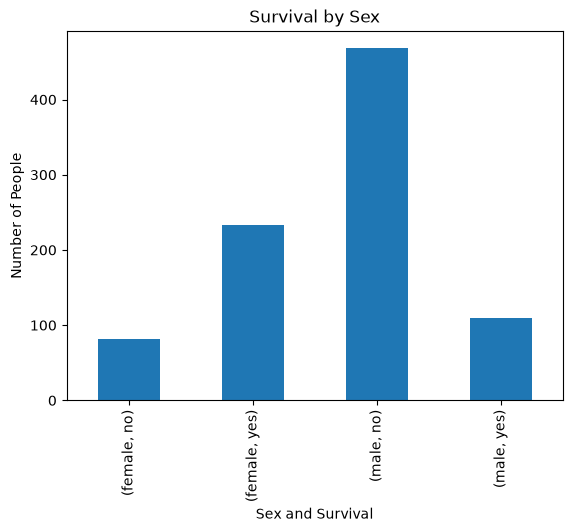

In [54]:
# TODO: survival rate by sex, by class (groupby + plots)


counts = (data.groupby(['sex', 'alive']).size())

counts.plot(kind='bar')

plt.xlabel('Sex and Survival')
plt.ylabel('Number of People')
plt.title('Survival by Sex')
plt.show()



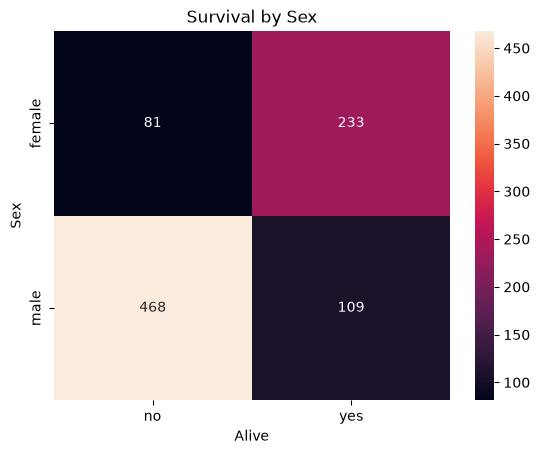

In [56]:
# TODO: correlation heatmap of numerical features
table = pd.crosstab(data['sex'], data['alive'])

sns.heatmap(table, annot=True, fmt='d')

plt.xlabel('Alive')
plt.ylabel('Sex')
plt.title('Survival by Sex')

plt.show()


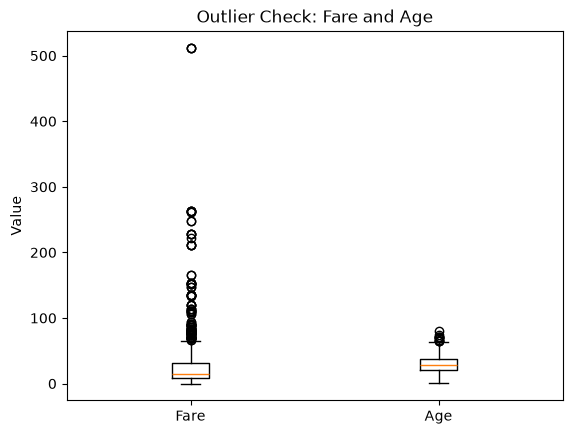

In [58]:
# TODO: outlier check on fare / age (boxplot or IQR)


plt.boxplot([data['fare'].dropna(), data['age'].dropna()])
plt.xticks([1, 2], ['Fare', 'Age'])
plt.ylabel('Value')
plt.title('Outlier Check: Fare and Age')
plt.show()


## 3. Handle missing values

Guiding questions:
- For `age`: does mean or median imputation make more sense given the distribution you plotted above? Or could you do something smarter (e.g., impute by title/class group)?
- For `cabin`: is it missing too much to salvage, or is "missingness itself" informative (e.g., could you engineer a `has_cabin` boolean instead of imputing)?
- For `embarked`: with only a couple missing, what's the simplest reasonable fix?

Write a sentence of reasoning above each fix before you code it — this is the habit that matters most in this stage.

Thoughts:
- The median imputation makes more sense given the dist since outliers will skew the data
-  Since approximately 77% of cabin values are missing, imputing specific cabin numbers would likely introduce unreliable information. Instead, I will create a has_cabin feature to preserve whether cabin information was available.
- Since only two values are missing, I will use mode imputation to preserve all observations while having minimal effect on the dataset


In [ ]:
# TODO: handle missing age

data['age'].describe()
median_age = data['age'].median()
data['age'] = data['age'].fillna(median_age)



count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

In [65]:
# TODO: handle missing cabin
data['has_cabin'] = data['deck'].notna()

In [64]:
# TODO: handle missing embarked
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])


## 4. Handle outliers

Guiding question: does the fare outlier represent bad data, or a real first-class passenger who paid a lot? Should you cap it, log-transform it, or leave it alone? Justify your choice.

Answer: Although there is a high fare outlier, it may represent a legitimate passenger who paid a significantly higher fare, rather than an error in the data. Since there is no evidence that the value is incorrect, I will leave it unchanged rather than removing potentially meaningful information.

In [ ]:
# TODO: outlier handling for fare

## 5. Feature engineering

Build at least 3 new features. Ideas to consider (think about what would actually help predict survival):
- Family size from `sibsp` + `parch`
- Title extracted from the `name` column (Mr/Mrs/Miss/Master/rare)
- `has_cabin` boolean from Section 3
- Fare-per-person (fare / family size)

In [76]:
# TODO: engineer new features

#Family Size
#data['new_column'] = data[] + data + ....
data['family_size'] = data['sibsp'] + data['parch'] + 1

#Has_cabin
data['has_cabin'] = data['deck'].notna()

#Fare-per-person
data['fare_per_person'] = data['fare'] / data['family_size']





## 6. Encode categorical variables

Guiding question: for `sex` (binary) vs. `embarked`/`title` (multi-category, no natural order) — should these be one-hot encoded, ordinal encoded, or something else? Why?


In [ ]:
# TODO: encode categoricals
data['sex'] = data['sex'].map({'male': 0, 'female': 1})

data = pd.get_dummies(data, columns=['embarked'], dtype=int)


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class',
       'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone',
       'has_cabin', 'family_size', 'fare_per_person', 'embarked_C',
       'embarked_Q', 'embarked_S'],
      dtype='str')


## 7. Train / validation / test split — WITH NO LEAKAGE

Critical rule: split FIRST, then fit any scaler/encoder on the training set only, then transform val/test using those already-fitted objects.

Guiding questions:
- Should this split be stratified on the target? Why?
- Where exactly in your pipeline could leakage sneak in if you weren't careful (e.g., if you'd imputed age using the *full* dataset's mean before splitting)?

In [ ]:
from sklearn.model_selection import train_test_split

# TODO: split into train/val/test (stratified on target)

X = data.drop(columns=['survived', 'alive'])
y = data['survived']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)


#print(X_train.shape)
#print(X_val.shape)
#print(X_test.shape)

#print(y_train.value_counts(normalize=True))
#print(y_val.value_counts(normalize=True))
#print(y_test.value_counts(normalize=True))




(623, 19)
(134, 19)
(134, 19)
survived
0    0.616372
1    0.383628
Name: proportion, dtype: float64
survived
0    0.61194
1    0.38806
Name: proportion, dtype: float64
survived
0    0.619403
1    0.380597
Name: proportion, dtype: float64


## 8. Scale numerical features

Fit the scaler on train only, then apply to val/test. Which scaler makes sense here — StandardScaler or something more robust to outliers, given what you found in Section 4?

In [85]:
# TODO: fit scaler on train, transform train/val/test
# We choose the scaler based on the distribution of our data, and we fit it only on the training set to prevent data leakage.

numeric_features = [
    'age',
    'fare',
    'family_size',
    'fare_per_person'
]
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scaler.fit(X_train[numeric_features])

X_train[numeric_features] = scaler.transform(X_train[numeric_features])
X_val[numeric_features] = scaler.transform(X_val[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])



## 9. Wrap-up

I handled missing `age` values using median imputation because the distribution contained outliers, making the median less sensitive to extreme values than the mean. For the highly incomplete cabin information, I created a `has_cabin` feature instead of attempting to impute specific cabin values, while using mode imputation for the small number of missing `embarked` values. I engineered `family_size`, `has_cabin`, and `fare_per_person` because family size, access to cabin information, and effective fare paid per person could provide useful information for predicting survival. To prevent data leakage, I split the data into training, validation, and test sets before fitting preprocessing steps such as imputation, encoding, and scaling, and fitted the `RobustScaler` only on the training data before transforming the validation and test sets.
